In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("../data/Used_Cars_Prices.csv")
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [3]:
df.shape

(4009, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 376.0 KB


In [5]:
df.describe()

,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


In [6]:
df.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.columns

Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='str')

In [9]:
df["price"].head()

0    $10,300
1    $38,005
2    $54,598
3    $15,500
4    $34,999
Name: price, dtype: str

In [10]:
df["milage"].head()

0    51,000 mi.
1    34,742 mi.
2    22,372 mi.
3    88,900 mi.
4     9,835 mi.
Name: milage, dtype: str

In [11]:
df["fuel_type"].value_counts(dropna=False)

fuel_type
Gasoline          3309
Hybrid             194
NaN                170
E85 Flex Fuel      139
Diesel             116
–                   45
Plug-In Hybrid      34
not supported        2
Name: count, dtype: int64

In [12]:
df["accident"].value_counts(dropna=False)

accident
None reported                             2910
At least 1 accident or damage reported     986
NaN                                        113
Name: count, dtype: int64

In [13]:
df["clean_title"].value_counts(dropna=False)

clean_title
Yes    3413
NaN     596
Name: count, dtype: int64

In [14]:
df["transmission"].value_counts(dropna=False)

transmission
A/T                                  1037
8-Speed A/T                           406
Transmission w/Dual Shift Mode        398
6-Speed A/T                           362
6-Speed M/T                           248
                                     ... 
7-Speed DCT Automatic                   1
9-Speed Automatic with Auto-Shift       1
SCHEDULED FOR OR IN PRODUCTION          1
6 Speed Mt                              1
8-Speed Manual                          1
Name: count, Length: 62, dtype: int64

In [15]:
df["engine"].sample(10)

1289    415.0HP 3.6L Flat 6 Cylinder Engine Gasoline Fuel
1330          835.0HP Electric Motor Electric Fuel System
2883         310.0HP 2.3L 4 Cylinder Engine Gasoline Fuel
2313                   2.0L I4 16V GDI DOHC Flexible Fuel
2455        340.0HP 3.0L V6 Cylinder Engine Gasoline Fuel
3816                     6.7L V12 48V GDI DOHC Twin Turbo
1871        375.0HP 3.5L V6 Cylinder Engine Gasoline Fuel
366         354.0HP 3.0L V6 Cylinder Engine Gasoline Fuel
3556         285.0HP 5.3L 8 Cylinder Engine Gasoline Fuel
3443        285.0HP 3.6L V6 Cylinder Engine Gasoline Fuel
Name: engine, dtype: str

In [16]:
df["price"] = df["price"].str.replace("$", "", regex=False)
df["price"] = df["price"].str.replace(",", "", regex=False)
df["price"] = pd.to_numeric(df["price"])

In [17]:
df["milage"] = df["milage"].str.replace(",", "", regex=False)
df["milage"] = df["milage"].str.replace(" mi.", "", regex=False)
df["milage"] = pd.to_numeric(df["milage"])

In [18]:
df["fuel_type"] = df["fuel_type"].replace("–", "Unknown")
df["fuel_type"] = df["fuel_type"].replace("not supported", "Unknown")
df["fuel_type"] = df["fuel_type"].fillna("Unknown")

In [19]:
df["accident"] = df["accident"].fillna("Unknown")

In [20]:
df["clean_title"] = df["clean_title"].fillna("Unknown")

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   int64
 4   fuel_type     4009 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      4009 non-null   str  
 10  clean_title   4009 non-null   str  
 11  price         4009 non-null   int64
dtypes: int64(3), str(9)
memory usage: 376.0 KB


In [22]:
df.isnull().sum()

brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
dtype: int64

In [23]:
df[["price", "milage"]].describe()

,price,milage
count,4.009000e+03,4009.000000
mean,4.455319e+04,64717.551010
std,7.871064e+04,52296.599459
min,2.000000e+03,100.000000
25%,1.720000e+04,23044.000000
50%,3.100000e+04,52775.000000
75%,4.999000e+04,94100.000000
max,2.954083e+06,405000.000000


In [24]:
current_year = 2026
df["car_age"] = current_year - df["model_year"]
df[["model_year","car_age"]].head()

,model_year,car_age
0,2013,13
1,2021,5
2,2022,4
3,2015,11
4,2021,5


In [25]:
df["car_age"].describe()

count    4009.000000
mean       10.484410
std         6.104816
min         2.000000
25%         6.000000
50%         9.000000
75%        14.000000
max        52.000000
Name: car_age, dtype: float64

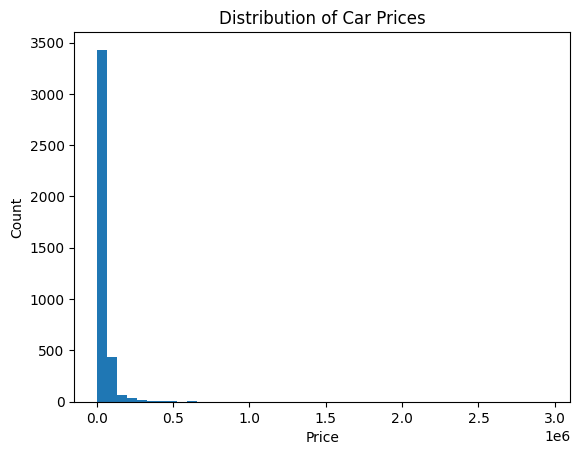

In [26]:
# Price Distribution
plt.hist(df["price"], bins=45)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Distribution of Car Prices")
plt.show()


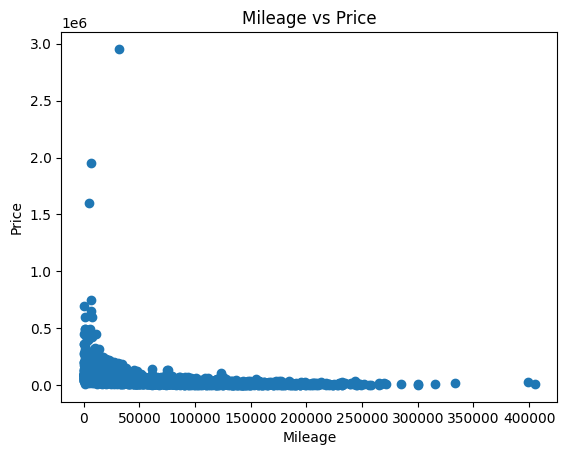

In [27]:
# Mileage vs Price
plt.scatter(df["milage"], df["price"])
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.title("Mileage vs Price")
plt.show()

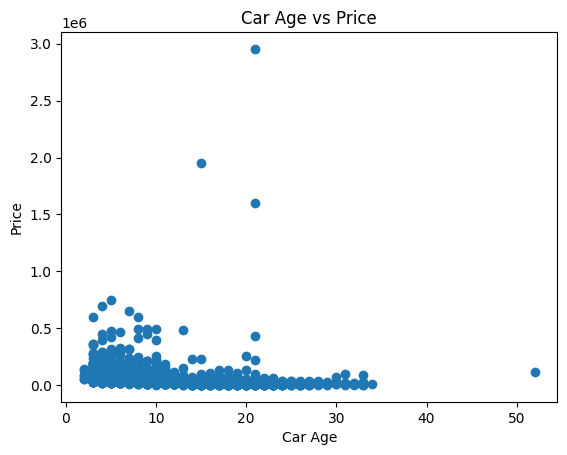

In [28]:
# Car Age vs Price
plt.scatter(df["car_age"], df["price"])
plt.xlabel("Car Age")
plt.ylabel("Price")
plt.title("Car Age vs Price")
plt.show()

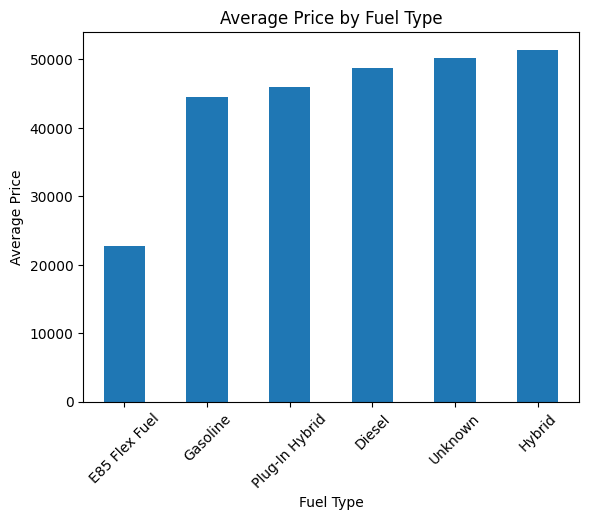

In [29]:
# Average Price By Fuel Type
df.groupby("fuel_type")["price"].mean().sort_values().plot(kind="bar")
plt.xlabel("Fuel Type")
plt.ylabel("Average Price")
plt.title("Average Price by Fuel Type")
plt.xticks(rotation=45)
plt.show()

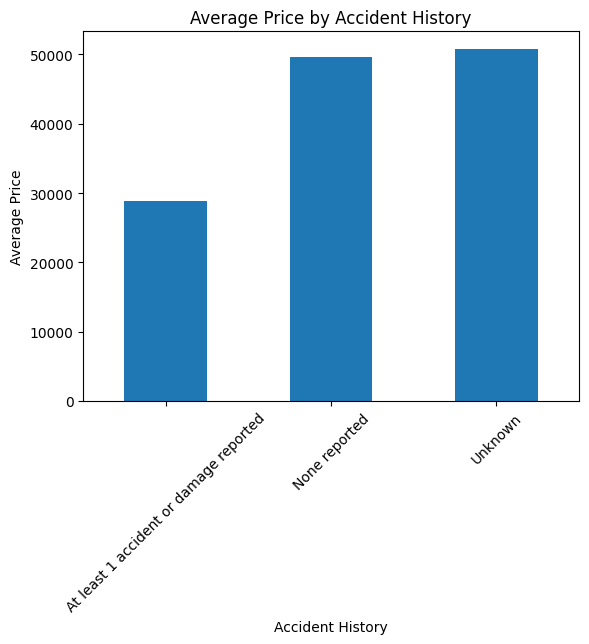

In [30]:
# Average Price By Accident History
df.groupby("accident")["price"].mean().sort_values().plot(kind="bar")
plt.xlabel("Accident History")
plt.ylabel("Average Price")
plt.title("Average Price by Accident History")
plt.xticks(rotation=45)
plt.show()

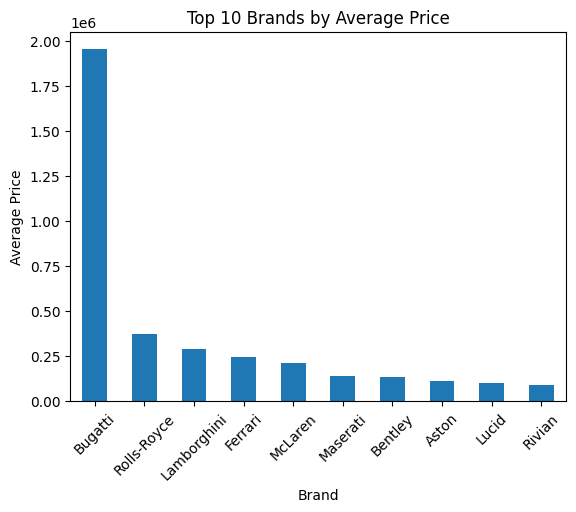

In [31]:
# Top 10 Brands By Average Price
df.groupby("brand")["price"].mean().sort_values(ascending=False).head(10).plot(kind="bar")
plt.xlabel("Brand")
plt.ylabel("Average Price")
plt.title("Top 10 Brands by Average Price")
plt.xticks(rotation=45)
plt.show()

In [32]:
# Check Price Statistics Before Outlier Handling
df["price"].describe()

count    4.009000e+03
mean     4.455319e+04
std      7.871064e+04
min      2.000000e+03
25%      1.720000e+04
50%      3.100000e+04
75%      4.999000e+04
max      2.954083e+06
Name: price, dtype: float64

In [33]:
# Check Price Percentiles
df["price"].quantile([0.90, 0.95, 0.97, 0.99])

0.90     79999.00
0.95    111600.00
0.97    149804.00
0.99    272713.28
Name: price, dtype: float64

In [34]:
# Row Count Before Removing Outliers
rows_before = df.shape[0]
rows_before

4009

In [35]:
# Remove Extreme Price Outliers Using 99th Percentile
price_limit = df["price"].quantile(0.99)
df = df[df["price"] <= price_limit]

In [36]:
# Row Count After Removing Outliers
rows_after = df.shape[0]

print("Rows Before Outlier Handling:", rows_before)
print("Rows After Outlier Handling:", rows_after)
print("Rows Removed:", rows_before - rows_after)
print("Price Limit Used:", price_limit)

Rows Before Outlier Handling: 4009
Rows After Outlier Handling: 3968
Rows Removed: 41
Price Limit Used: 272713.2800000002


In [37]:
# Check Price Statistics After Outlier Handling
df["price"].describe()

count      3968.000000
mean      39550.042591
std       34833.812521
min        2000.000000
25%       17000.000000
50%       30969.500000
75%       48998.250000
max      269991.000000
Name: price, dtype: float64

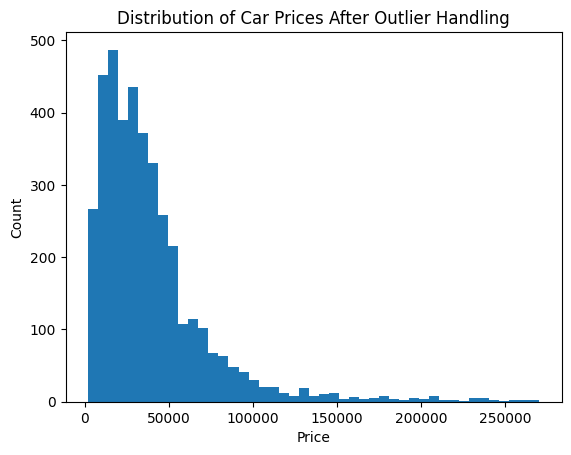

In [38]:
# Price Distribution After Outlier Handling
plt.hist(df["price"], bins=45)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Distribution of Car Prices After Outlier Handling")
plt.savefig("../images/price_distribution.png", bbox_inches="tight")
plt.show()

In [39]:
selected_features = [
    "brand",
    "model_year",
    "milage",
    "fuel_type",
    "transmission",
    "accident",
    "clean_title",
    "car_age"
]

X = df[selected_features]
y = df["price"]

In [40]:
X.head()

,brand,model_year,milage,fuel_type,transmission,accident,clean_title,car_age
0,Ford,2013,51000,E85 Flex Fuel,6-Speed A/T,At least 1 accident or damage reported,Yes,13
1,Hyundai,2021,34742,Gasoline,8-Speed Automatic,At least 1 accident or damage reported,Yes,5
2,Lexus,2022,22372,Gasoline,Automatic,None reported,Unknown,4
3,INFINITI,2015,88900,Hybrid,7-Speed A/T,None reported,Yes,11
4,Audi,2021,9835,Gasoline,8-Speed Automatic,None reported,Unknown,5


In [41]:
X.shape

(3968, 8)

In [42]:
y.head()

0    10300
1    38005
2    54598
3    15500
4    34999
Name: price, dtype: int64

In [43]:
# Encode Categorical Columns
categorical_columns = [
    "brand",
    "fuel_type",
    "transmission",
    "accident",
    "clean_title"
]

X_encoded = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

X_encoded.head()

,model_year,milage,car_age,brand_Alfa,brand_Aston,brand_Audi,brand_BMW,brand_Bentley,brand_Buick,brand_Cadillac,...,"transmission_Manual, 6-Spd",transmission_SCHEDULED FOR OR IN PRODUCTION,transmission_Single-Speed Fixed Gear,transmission_Transmission Overdrive Switch,transmission_Transmission w/Dual Shift Mode,transmission_Variable,transmission_–,accident_None reported,accident_Unknown,clean_title_Yes
0,2013,51000,13,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,2021,34742,5,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,2022,22372,4,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,2015,88900,11,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
4,2021,9835,5,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [44]:
X_encoded.shape

(3968, 125)

In [45]:
X_encoded.info()

<class 'pandas.DataFrame'>
Index: 3968 entries, 0 to 4008
Columns: 125 entries, model_year to clean_title_Yes
dtypes: bool(122), int64(3)
memory usage: 596.8 KB


In [46]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size = 0.2,
    random_state = 42
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (3174, 125)
X_test Shape: (794, 125)
y_train Shape: (3174,)
y_test Shape: (794,)


In [47]:
# Train Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Train Decision Tree Regressor
decision_tree_model = DecisionTreeRegressor(random_state=42)
decision_tree_model.fit(X_train, y_train)

# Train Random Forest Regressor
random_forest_model = RandomForestRegressor(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)

# Train XGBoost Regressor
xgboost_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    objective="reg:squarederror")
xgboost_model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [48]:
# Function To Evaluate A Regression Model
def evaluate_model(model_name, model):
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, y_pred)
    
    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2_Score": r2
    }

In [49]:
# Evaluate All Trained Models
results = []

results.append(evaluate_model("Linear Regression", linear_model))
results.append(evaluate_model("Decision Tree Regressor", decision_tree_model))
results.append(evaluate_model("Random Forest Regressor", random_forest_model))
results.append(evaluate_model("XGBoost Regressor", xgboost_model))

In [50]:
# Convert Results Into A DataFrame
results_df = pd.DataFrame(results)

# Display Model Evaluation Results
results_df

,Model,MAE,MSE,RMSE,R2_Score
0,Linear Regression,15259.525365,5.550158e+08,23558.773093,0.528381
1,Decision Tree Regressor,15764.468514,6.379227e+08,25257.131835,0.457931
2,Random Forest Regressor,12392.168532,4.060147e+08,20149.806471,0.654993
3,XGBoost Regressor,12247.513672,3.855485e+08,19635.390090,0.672384


In [51]:
# Sort Models By RMSE & R2 Score
results_df.sort_values(by="RMSE", ascending=True)
results_df.sort_values(by="R2_Score", ascending=False)

,Model,MAE,MSE,RMSE,R2_Score
3,XGBoost Regressor,12247.513672,3.855485e+08,19635.390090,0.672384
2,Random Forest Regressor,12392.168532,4.060147e+08,20149.806471,0.654993
0,Linear Regression,15259.525365,5.550158e+08,23558.773093,0.528381
1,Decision Tree Regressor,15764.468514,6.379227e+08,25257.131835,0.457931


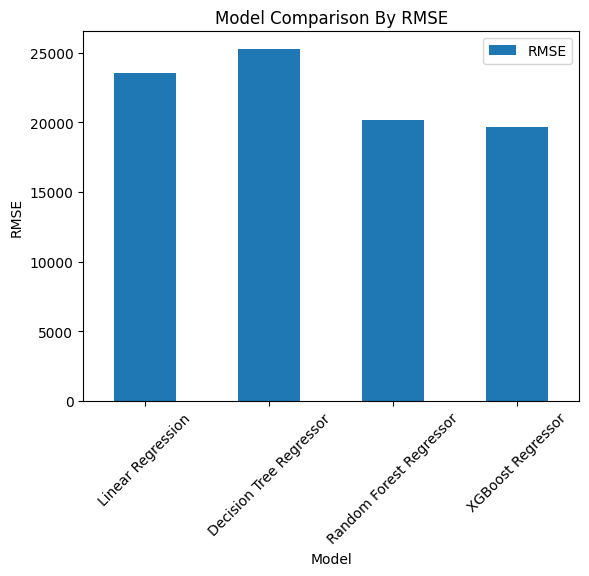

In [52]:
# Compare Models Using RMSE
results_df.plot(x="Model", y="RMSE", kind="bar")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Model Comparison By RMSE")
plt.xticks(rotation=45)
plt.savefig("../images/model_comparison_rmse.png", bbox_inches="tight")
plt.show()

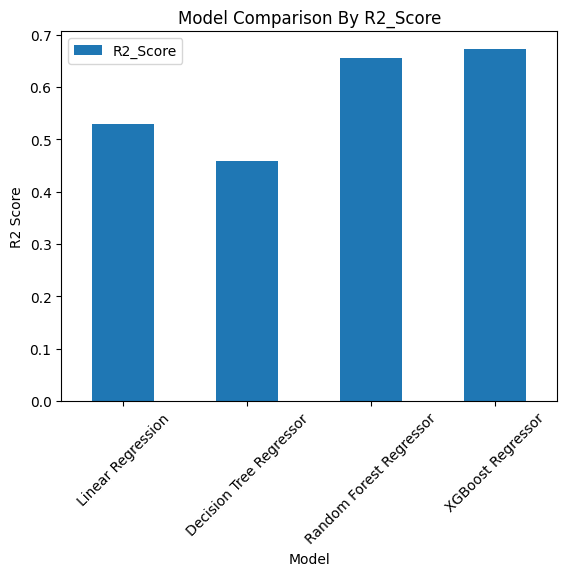

In [53]:
# Compare Models Using R2_Score
results_df.plot(x="Model", y="R2_Score", kind="bar")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.title("Model Comparison By R2_Score")
plt.xticks(rotation=45)
plt.savefig("../images/model_comparison_r2.png", bbox_inches="tight")
plt.show()

In [54]:
feature_importance = xgboost_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": feature_importance
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df.head(20)

,Feature,Importance
26,brand_Lamborghini,0.119871
96,transmission_9-Speed Automatic,0.065083
44,brand_Porsche,0.064903
1,milage,0.060712
14,brand_Ferrari,0.052266
7,brand_Bentley,0.049105
86,transmission_7-Speed Automatic with Auto-Shift,0.047808
27,brand_Land,0.040204
33,brand_Maserati,0.022817
47,brand_Rolls-Royce,0.022748


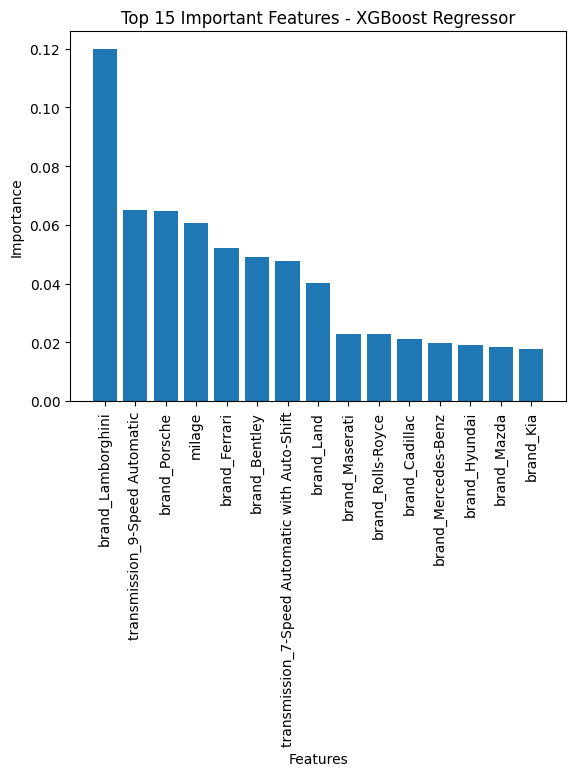

In [55]:
# Plot Top 15 Most Important Features
top_features = feature_importance_df.head(15)

plt.bar(top_features["Feature"], top_features["Importance"])
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Top 15 Important Features - XGBoost Regressor")
plt.xticks(rotation=90)
plt.savefig("../images/feature_importance.png", bbox_inches="tight")
plt.show()

In [56]:
# Create New Car Data
new_used_car_details = pd.DataFrame({
    "brand": ["Toyota"],
    "model_year": [2020],
    "milage": [45000],
    "fuel_type": ["Gasoline"],
    "transmission": ["6-Speed A/T"],
    "accident" : ["None reported"],
    "clean_title": ["Yes"],
    "car_age": [2026 - 2020]
})

# Encode New Car Data
new_used_car_encoded = pd.get_dummies(new_used_car_details)

# Match New Car Columns With Training Data Columns
new_used_car_encoded = new_used_car_encoded.reindex(
    columns=X_encoded.columns,
    fill_value=0
)

# Predict Price Using The Best Model
predicted_price = xgboost_model.predict(new_used_car_encoded)

# Display Predicted Price
print(f"Predicted Car Price: ${predicted_price[0]:,.2f}")

Predicted Car Price: $41,841.09
